<a href="https://colab.research.google.com/github/dandan8585/challegen2-danger-malaga/blob/main/TelecomX_LATAM_caso_1_Callegen_2_Danger_Malaga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [621]:
import requests
import pandas as pd

In [622]:
url = "https://raw.githubusercontent.com/dandan8585/challegen2-danger-malaga/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [623]:
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

In [624]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

**VERIFICACIONES**

---1. Verificando valores unicos



In [625]:
for col in df.columns:
  print(f'{col}: {df[col].nunique()}')
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)

customerID: 7267
Churn: 3
['No' 'Yes' '']
--------------------------------------------------
customer.gender: 2
['Female' 'Male']
--------------------------------------------------
customer.SeniorCitizen: 2
[0 1]
--------------------------------------------------
customer.Partner: 2
['Yes' 'No']
--------------------------------------------------
customer.Dependents: 2
['Yes' 'No']
--------------------------------------------------
customer.tenure: 73
phone.PhoneService: 2
['Yes' 'No']
--------------------------------------------------
phone.MultipleLines: 3
['No' 'Yes' 'No phone service']
--------------------------------------------------
internet.InternetService: 3
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
internet.OnlineSecurity: 3
['No' 'Yes' 'No internet service']
--------------------------------------------------
internet.OnlineBackup: 3
['Yes' 'No' 'No internet service']
--------------------------------------------------
internet.DeviceProtecti

*2*. Valores Duplicados

In [626]:
print("Numero de duplicados", df.duplicated().sum())

Numero de duplicados 0


3. Valores nulos

In [627]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


4. Vacíos o en blanco

In [628]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


cambiando columna account.charges.total a float y verificacion de datos en blanco

In [629]:
# Ensure the column exists before converting to numeric
# This step is added here to make the conversion cell more robust to execution order
# The column 'account.Charges.Total' is renamed to 'total_cobrado' in cell kN69JKMRL3bz
# But if that cell is not executed, this will handle the rename locally.
if 'account.Charges.Total' in df.columns:
    df = df.rename(columns={'account.Charges.Total': 'total_cobrado'})

df['total_cobrado'] = pd.to_numeric(df['total_cobrado'], errors='coerce')

In [630]:
print("Number of missing values in 'total_cobrado':", df['total_cobrado'].isnull().sum())

Number of missing values in 'total_cobrado': 11


In [631]:
print("Number of missing values in 'total_cobrado':", df['total_cobrado'].isnull().sum())

Number of missing values in 'total_cobrado': 11


In [632]:
df= df[df['Churn'].str.strip() != '']
print("Número de filas después de eliminar las vacías en 'Churn':", len(df))

Número de filas después de eliminar las vacías en 'Churn': 7043


In [633]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [634]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
total_cobrado                11
dtype: int64


In [635]:
df = df.dropna(subset=['total_cobrado'])

In [636]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
total_cobrado                0
dtype: int64


In [637]:
df.to_csv('TelecomX_Data.csv', index=False)

In [638]:
if 'valor_mensal' in df.columns:
    print("The column 'valor_mensal' exists in the DataFrame.")
else:
    print("The column 'valor_mensal' does NOT exist in the DataFrame.")
print("Current columns in DataFrame:", df.columns.tolist())

The column 'valor_mensal' does NOT exist in the DataFrame.
Current columns in DataFrame: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'total_cobrado']


In [639]:
print(df.columns)

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'total_cobrado'],
      dtype='object')


In [640]:
columnas = {                                                        # Diccionario con los nuevos nombres de las columnas.
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tiene +60',
    'customer.Partner': 'posee_pareja',
    'customer.Dependents': 'posee_dependientes',
    'customer.tenure': 'tiempo_contrato',
    'phone.PhoneService': 'servicio_telefono',
    'phone.MultipleLines': 'multiples_lineas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_digital',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns= columnas)
print("Columns after renaming:", df.columns.tolist())

Columns after renaming: ['id', 'Churn', 'genero', 'tiene +60', 'posee_pareja', 'posee_dependientes', 'tiempo_contrato', 'servicio_telefono', 'multiples_lineas', 'tipo_internet', 'seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'factura_digital', 'metodo_pago', 'valor_mensal', 'total_cobrado']


In [641]:
df['Churn'] = df['Churn'].replace({'No': 'No', 'Yes': 'Sí'})
df['genero'] = df['genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
df['posee_pareja'] = df['posee_pareja'].replace({'Yes': 'Sí', 'No': 'No'})
df['posee_dependientes'] = df['posee_dependientes'].replace({'Yes': 'Sí', 'No': 'No'})
df['servicio_telefono'] = df['servicio_telefono'].replace({'Yes': 'Sí', 'No': 'No'})
df['multiples_lineas'] = df['multiples_lineas'].replace({'No': 'No', 'Yes': 'Sí', 'No phone service': 'Sin servicio de teléfono'})
df['tipo_internet'] = df['tipo_internet'].replace({'No': 'No'})
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensual', 'Two year': 'Bienal'})
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,Yes,No,Yes,Yes,No,Anual,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,No,Yes,Mensual,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,No,Yes,No,No,No,Mensual,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Mensual,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,No,Yes,Yes,No,Mensual,Yes,Mailed check,83.9,267.40


In [642]:
columnas_a_traducir = ['seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas']
mapeo = {'No': 'No', 'Yes': 'Sí', 'No internet service': 'Sin servicio de internet'}

for col in columnas_a_traducir:
    df[col] = df[col].replace(mapeo)

df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,Sí,No,Sí,Sí,No,Anual,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,No,Sí,Mensual,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,No,Sí,No,No,No,Mensual,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Sí,Sí,No,Sí,Sí,Mensual,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,No,Sí,Sí,No,Mensual,Yes,Mailed check,83.9,267.40


In [643]:
df['metodo_pago'] = df['metodo_pago'].replace({
    'Mailed check': 'Cheque enviado por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automático)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)'
})
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,Sí,No,Sí,Sí,No,Anual,Yes,Cheque enviado por correo,65.6,593.30
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9,542.40
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,No,Sí,No,No,No,Mensual,Yes,Cheque electrónico,73.9,280.85
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Sí,Sí,No,Sí,Sí,Mensual,Yes,Cheque electrónico,98.0,1237.85
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,No,Sí,Sí,No,Mensual,Yes,Cheque enviado por correo,83.9,267.40


In [644]:
df

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,Sí,No,Sí,Sí,No,Anual,Yes,Cheque enviado por correo,65.60,593.30
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.90,542.40
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,No,Sí,No,No,No,Mensual,Yes,Cheque electrónico,73.90,280.85
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Sí,Sí,No,Sí,Sí,Mensual,Yes,Cheque electrónico,98.00,1237.85
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,No,Sí,Sí,No,Mensual,Yes,Cheque enviado por correo,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Femenino,0,No,No,13,Sí,No,DSL,...,No,No,Sí,No,No,Anual,No,Cheque enviado por correo,55.15,742.90
7263,9992-RRAMN,Sí,Masculino,0,Sí,No,22,Sí,Sí,Fiber optic,...,No,No,No,No,Sí,Mensual,Yes,Cheque electrónico,85.10,1873.70
7264,9992-UJOEL,No,Masculino,0,No,No,2,Sí,No,DSL,...,Sí,No,No,No,No,Mensual,Yes,Cheque enviado por correo,50.30,92.75
7265,9993-LHIEB,No,Masculino,0,Sí,Sí,67,Sí,No,DSL,...,No,Sí,Sí,No,Sí,Bienal,No,Cheque enviado por correo,67.85,4627.65


#📊 Carga y análisis

1.Analisis Descriptiva

In [645]:
df.describe()

,tiene +60,tiempo_contrato,valor_mensal,total_cobrado
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


2. Distribución de la Evasión

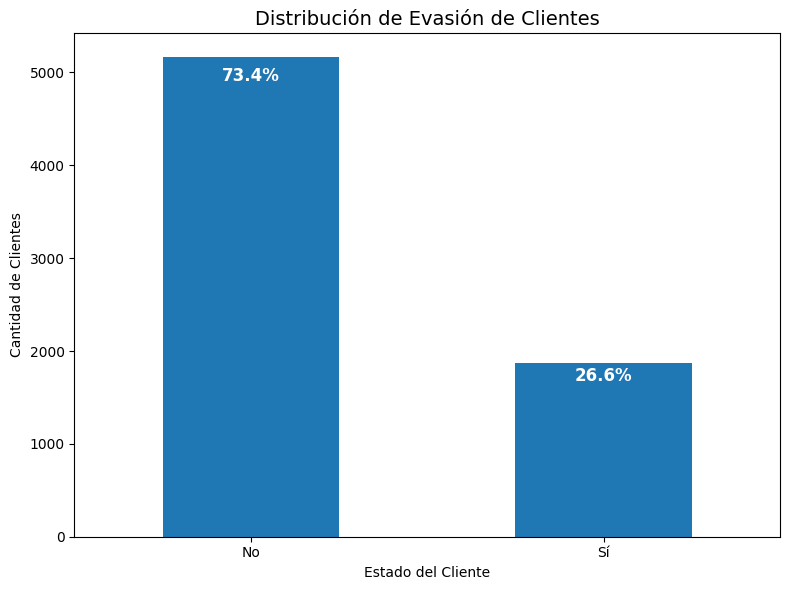

In [646]:
import matplotlib.pyplot as plt

# Calcular métricas
churn_counts = df['Churn'].value_counts()
churn_percentages = (churn_counts / churn_counts.sum()) * 100

plt.figure(figsize=(8,6))
ax = churn_counts.plot(kind='bar')

plt.title('Distribución de Evasión de Clientes', fontsize=14)
plt.xlabel('Estado del Cliente')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)

# Agregar etiquetas con porcentaje
for i in range(len(churn_counts)):
    ax.text(i,
            churn_counts.iloc[i] * 0.98,
            f'{churn_percentages.iloc[i]:.1f}%',
            ha='center',
            va='top',
            color='white',
            fontsize=12,
            fontweight='bold')

plt.tight_layout()
plt.show()

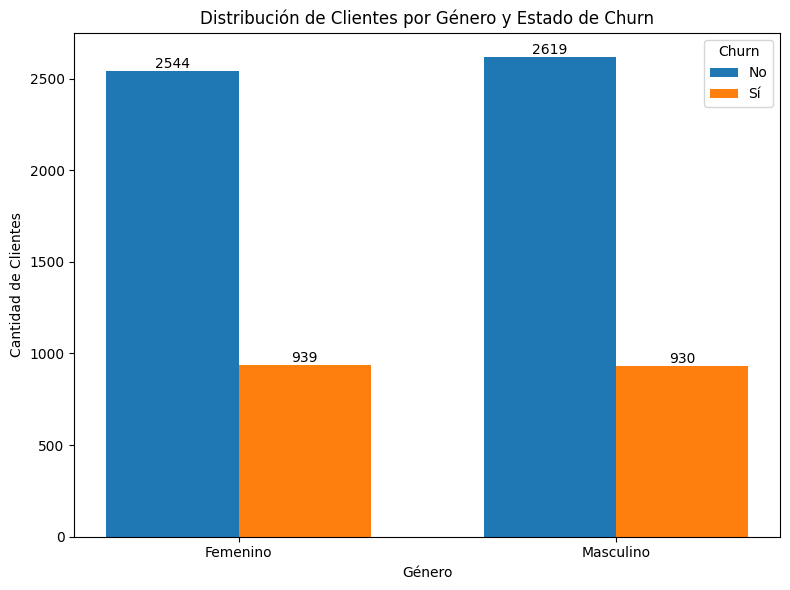

In [647]:
import matplotlib.pyplot as plt
import numpy as np

# Agrupar datos
grouped = df.groupby(['genero', 'Churn']).size().unstack()

# Posiciones
x = np.arange(len(grouped.index))
width = 0.35

plt.figure(figsize=(8,6))

# Barras agrupadas
bars1 = plt.bar(x - width/2, grouped.iloc[:,0], width, label=grouped.columns[0])
bars2 = plt.bar(x + width/2, grouped.iloc[:,1], width, label=grouped.columns[1])

# Títulos
plt.title('Distribución de Clientes por Género y Estado de Churn')
plt.xlabel('Género')
plt.ylabel('Cantidad de Clientes')
plt.xticks(x, grouped.index)
plt.legend(title='Churn')

# Etiquetas encima de barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{int(height)}',
                 ha='center',
                 va='bottom')

plt.tight_layout()
plt.show()

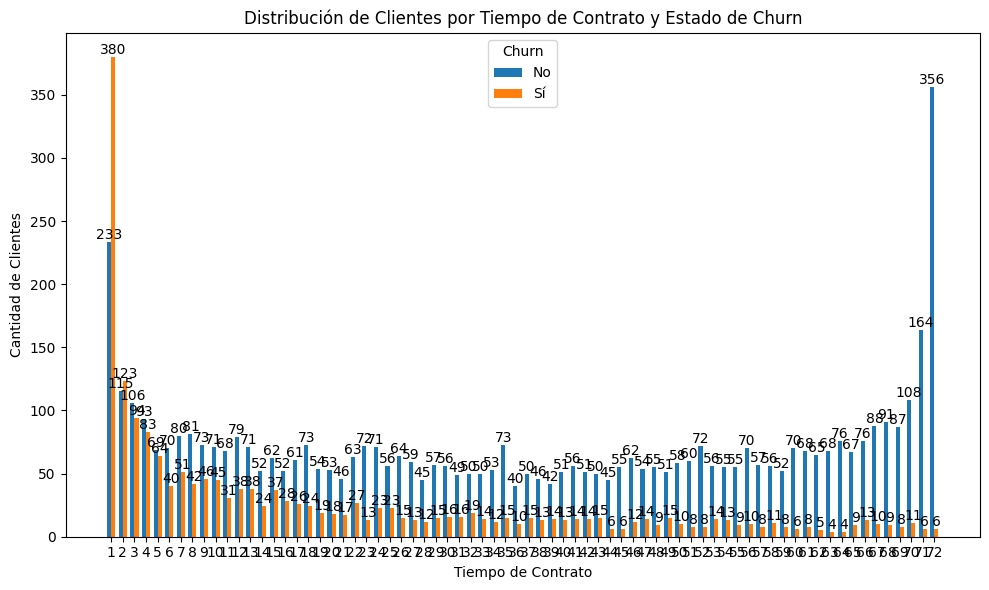

In [648]:
import matplotlib.pyplot as plt
import numpy as np

# Agrupar datos
grouped = df.groupby(['tiempo_contrato', 'Churn']).size().unstack()

# Posiciones en eje X
x = np.arange(len(grouped.index))
width = 0.35

plt.figure(figsize=(10,6))

# Barras agrupadas
bars1 = plt.bar(x - width/2, grouped.iloc[:,0], width, label=grouped.columns[0])
bars2 = plt.bar(x + width/2, grouped.iloc[:,1], width, label=grouped.columns[1])

# Títulos y etiquetas
plt.title('Distribución de Clientes por Tiempo de Contrato y Estado de Churn')
plt.xlabel('Tiempo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.xticks(x, grouped.index, rotation=0)
plt.legend(title='Churn')

# Etiquetas encima de cada barra
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{int(height)}',
                 ha='center',
                 va='bottom',
                 fontsize=10)

plt.tight_layout()
plt.show()

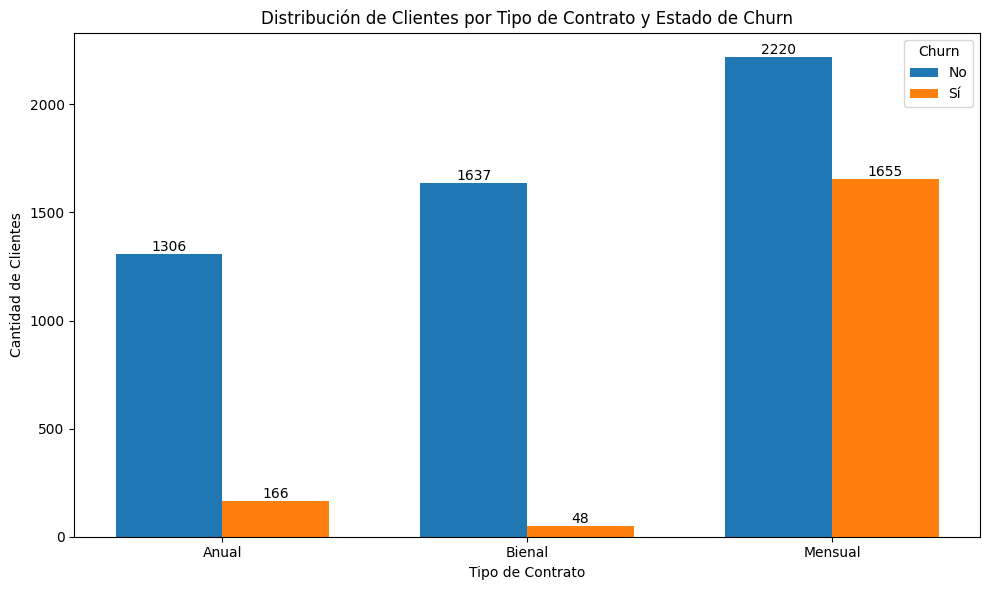

In [649]:
import matplotlib.pyplot as plt
import numpy as np

# Agrupar datos
grouped = df.groupby(['tipo_contrato', 'Churn']).size().unstack()

# Posiciones eje X
x = np.arange(len(grouped.index))
width = 0.35

plt.figure(figsize=(10,6))

# Barras agrupadas
bars1 = plt.bar(x - width/2, grouped.iloc[:,0], width, label=grouped.columns[0])
bars2 = plt.bar(x + width/2, grouped.iloc[:,1], width, label=grouped.columns[1])

# Títulos y etiquetas
plt.title('Distribución de Clientes por Tipo de Contrato y Estado de Churn')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.xticks(x, grouped.index, rotation=0)
plt.legend(title='Churn')

# Etiquetas numéricas
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{int(height)}',
                 ha='center',
                 va='bottom',
                 fontsize=10)

plt.tight_layout()
plt.show()

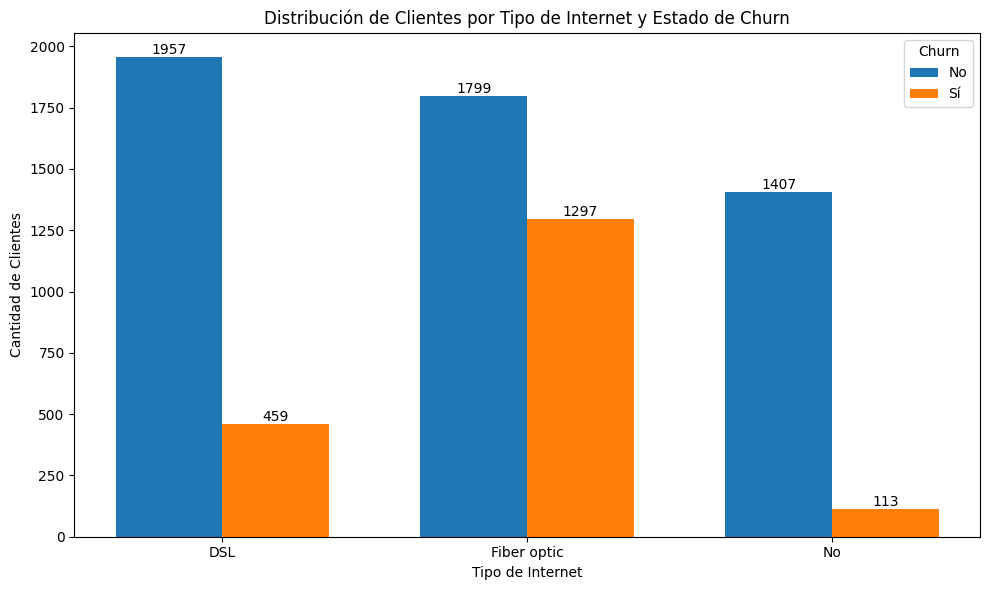

In [650]:
import matplotlib.pyplot as plt
import numpy as np

# Agrupar datos
grouped = df.groupby(['tipo_internet', 'Churn']).size().unstack()

# Posiciones eje X
x = np.arange(len(grouped.index))
width = 0.35

plt.figure(figsize=(10,6))

# Barras agrupadas
bars1 = plt.bar(x - width/2, grouped.iloc[:,0], width, label=grouped.columns[0])
bars2 = plt.bar(x + width/2, grouped.iloc[:,1], width, label=grouped.columns[1])

# Títulos
plt.title('Distribución de Clientes por Tipo de Internet y Estado de Churn')
plt.xlabel('Tipo de Internet')
plt.ylabel('Cantidad de Clientes')
plt.xticks(x, grouped.index, rotation=0)
plt.legend(title='Churn')

# Etiquetas encima
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{int(height)}',
                 ha='center',
                 va='bottom',
                 fontsize=10)

plt.tight_layout()
plt.show()

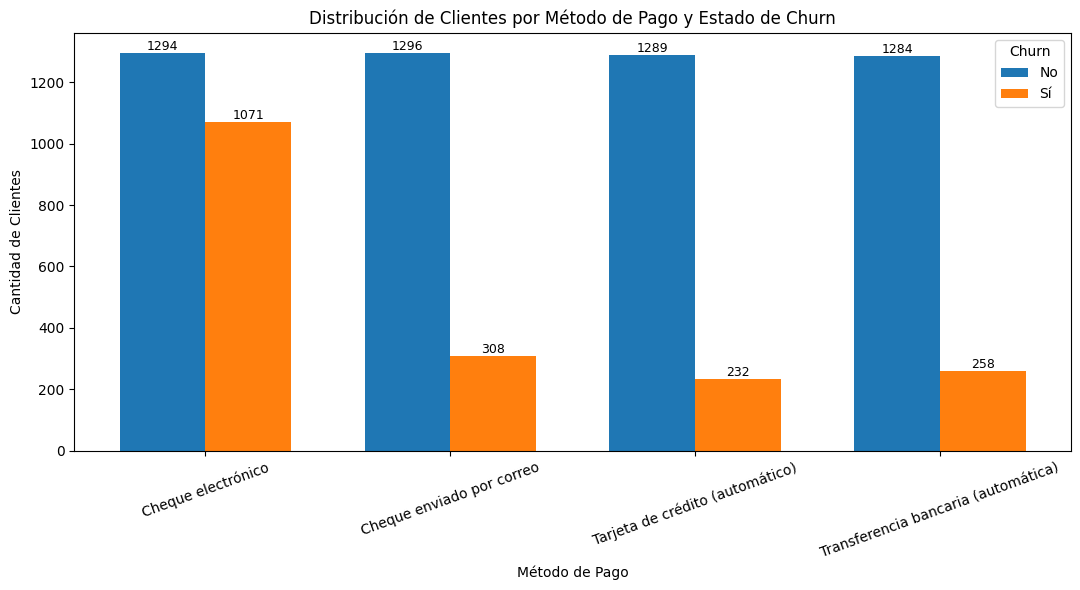

In [651]:
import matplotlib.pyplot as plt
import numpy as np

# Agrupar datos
grouped = df.groupby(['metodo_pago', 'Churn']).size().unstack()

# Posiciones eje X
x = np.arange(len(grouped.index))
width = 0.35

plt.figure(figsize=(11,6))

# Barras agrupadas
bars1 = plt.bar(x - width/2, grouped.iloc[:,0], width, label=grouped.columns[0])
bars2 = plt.bar(x + width/2, grouped.iloc[:,1], width, label=grouped.columns[1])

# Títulos y etiquetas
plt.title('Distribución de Clientes por Método de Pago y Estado de Churn')
plt.xlabel('Método de Pago')
plt.ylabel('Cantidad de Clientes')
plt.xticks(x, grouped.index, rotation=20)
plt.legend(title='Churn')

# Etiquetas numéricas
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{int(height)}',
                 ha='center',
                 va='bottom',
                 fontsize=9)

plt.tight_layout()
plt.show()

#📄Informe final

**1. Analisis Actual**

El análisis del comportamiento de clientes evidencia que la evasión (churn) no es aleatoria, sino estructural y altamente concentrada en segmentos específicos.

     *   Los principales factores asociados a cancelación son:
     *   Contratos mensuales
     *   Baja antigüedad (0–6 meses)
     *   Cargos mensuales elevados
     *   Ausencia de servicios complementarios (soporte, seguridad)
     *   Métodos de pago no automatizados
________________________________________________________________
   El riesgo se concentra en clientes recientemente adquiridos bajo contratos flexibles, lo que compromete la recuperación del costo de adquisición (CAC) y reduce el Lifetime Value (LTV).
________________________________________________________________
**2. Hallazgos Clave con Impacto Estratégico**

    - Contrato mensual = mayor rotación
      La flexibilidad contractual incrementa adquisición pero también la tasa de cancelación.

    - Primeros meses críticos
      La mayor pérdida ocurre antes de consolidar la relación comercial.

    - Servicios adicionales reducen churn
      Clientes con soporte técnico y protección digital presentan menor probabilidad de fuga.

    - Automatización de pagos reduce cancelación
      Métodos automáticos generan mayor estabilidad financiera.

**3. Impacto Financiero Estimado**
    
       * Base estimada: 10.000 clientes
       * ARPU promedio: USD 70 mensuales
       * Tasa de churn estimada: 26% anual
       * LTV promedio actual: ~ USD 1.400
       * Escenario de mejora conservadora:
       * Reducción del churn en 5 puntos porcentuales (26% → 21%)

Impacto estimado:

        * Retención adicional: 500 clientes
        *  Ingreso anual retenido:
        * 500 × 70 × 12 = USD 420.000
        * Incremento estimado en LTV promedio: +18%
        * Mejora en margen operativo por reducción de CAC relativo
        * Escenario moderado:
        * Reducción del churn en 8 puntos porcentuales

Retención adicional: 800 clientes

Ingreso anual retenido:
800 × 70 × 12 = USD 672.000

> "Estos valores no consideran ventas cruzadas adicionales ni mejoras en ARPU, por lo que el impacto real podría ser superior".

4. Palancas Estratégicas Prioritarias
**texto en negrita**
Programa de retención temprana (0–6 meses)

      ✔      Seguimiento activo post-venta
      ✔      Contacto preventivo
      ✔      Incentivos por permanencia inicial
      ✔      Migración a contratos anuales
      ✔      Descuento estructurado
      ✔      Beneficio agregado (seguridad o soporte premium)
      ✔      Bundling obligatorio inteligente
      ✔      Incorporar servicios de soporte como parte del paquete base
      ✔      Migración a débito automático
      ✔      Bonificación por activación
      ✔      Incentivo de fidelización progresivo

5**. Conclusión **

> El churn representa una fuga significativa de ingresos recurrentes, pero es gestionable.

> La compañía posee capacidad analítica suficiente para segmentar clientes de alto riesgo y ejecutar acciones focalizadas con retorno financiero directo y medible.

> Una reducción moderada de la tasa de evasión puede generar entre USD 420.000 y USD 670.000 adicionales anuales, además de fortalecer estabilidad financiera, flujo de caja y rentabilidad estructural.

> El enfoque no debe ser únicamente adquirir más clientes, sino maximizar el valor de los ya captados mediante una estrategia sistemática de retención inteligente.